## Dataset

**Name:** AI Jobs Market 2025-2026

**Source:** [https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries](https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries)

## Research Questions

**RQ1: An exploratory/descriptive question suited to EDA and unsupervised methods.**

What are the common characteristics and distributions of AI/ML job roles, experience levels, and educational requirements across different countries in the 2025-2026 job market?

**RQ2: A predictive or inferential question suited to supervised modeling.**

Can work modality (remote, hybrid, or in-office) significantly predict the salary range for AI/ML job positions in 2025-2026, after accounting for factors like experience level, education, and country?

# Section 0 | Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde

from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier

# Section 1 | Data Ingestion

In [3]:
# Colab upload helper
try:
    from google.colab import files
    uploaded = files.upload()
    print('Uploaded files:', list(uploaded.keys()))
except Exception as e:
    print('Colab upload is optional. If you are not in Colab, skip this cell.')
    print(type(e).__name__, '-', e)

Saving ai_jobs_market_2025_2026.csv to ai_jobs_market_2025_2026.csv
Uploaded files: ['ai_jobs_market_2025_2026.csv']


In [4]:
df = pd.read_csv('ai_jobs_market_2025_2026.csv')
print(df.shape)
display(df.head())

(1500, 25)


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


### Check for Missing Values

In [5]:
missing_values = df.isnull().sum()

if missing_values.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values in each column:")
    print(missing_values[missing_values > 0])

No missing values found.


### Check for Duplicate Records

In [6]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New DataFrame shape: {df.shape}")

Number of duplicate rows: 0


### Verify Data Types

In [7]:
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   o

### Display Descriptive Statistics for Numerical Columns

In [8]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

Descriptive statistics for numerical columns:


,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,6.216000,194892.000000,135448.666667,257537.333333,10.858200,87.523333,31.116333,7.897333,2025.584000,3.968000,0.496667,0.754000,0.218000
std,2.675216,66506.822013,24448.950878,39852.822207,4.029742,8.026315,22.046343,1.102846,0.493058,3.270388,0.500156,0.430822,0.413025
min,1.000000,90000.000000,90000.000000,180000.000000,3.000000,68.000000,5.000000,6.000000,2025.000000,1.000000,0.000000,0.000000,0.000000
25%,4.000000,144750.000000,120000.000000,218000.000000,8.200000,82.000000,15.375000,6.900000,2025.000000,2.000000,0.000000,1.000000,0.000000
50%,6.000000,180000.000000,140000.000000,270000.000000,10.500000,89.000000,23.400000,7.900000,2026.000000,3.000000,0.000000,1.000000,0.000000
75%,8.000000,236250.000000,155000.000000,290000.000000,14.200000,95.000000,42.700000,8.900000,2026.000000,5.000000,1.000000,1.000000,0.000000
max,15.000000,384000.000000,180000.000000,320000.000000,18.000000,98.000000,87.800000,9.800000,2026.000000,12.000000,1.000000,1.000000,1.000000


# Section 2 | Exploratory Data Analysis

### Job Category Distribution Across Top Countries


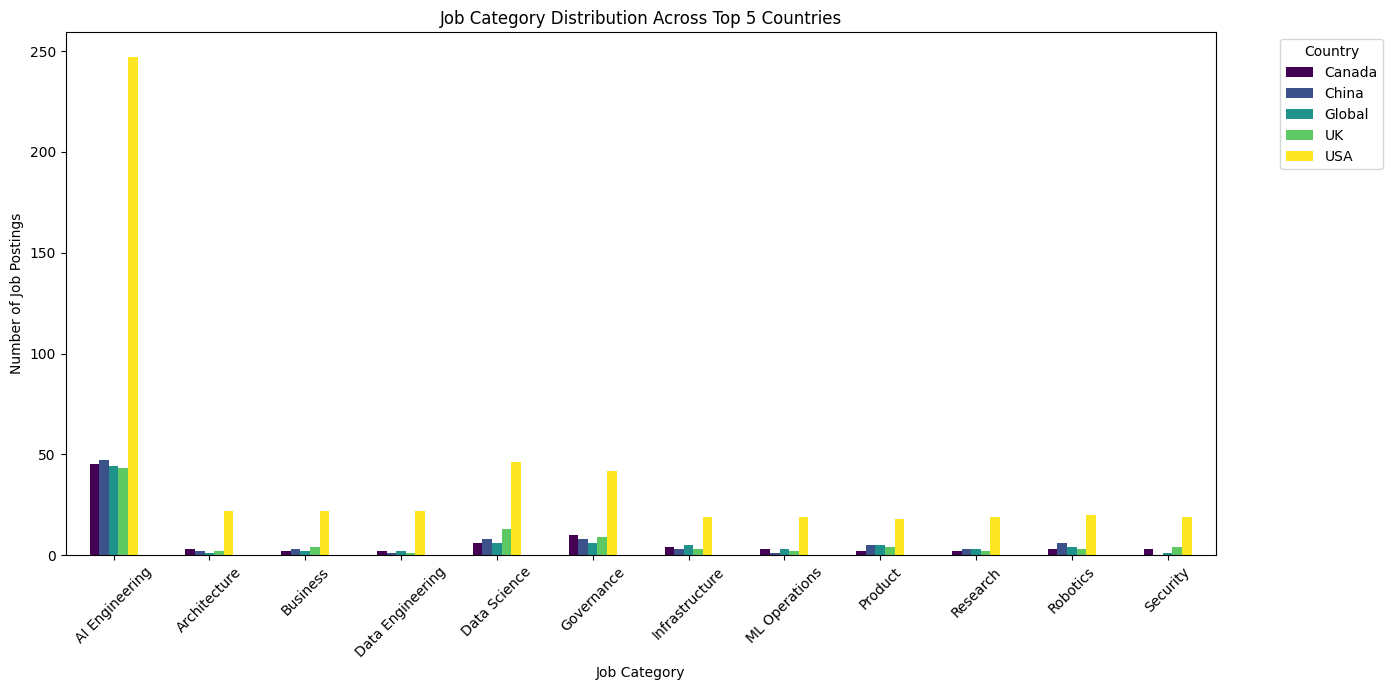

In [9]:
# Get the top N countries based on job postings
top_countries = df['country'].value_counts().nlargest(5).index

# Filter the DataFrame to include only job postings from top countries
df_top_countries = df[df['country'].isin(top_countries)]

# Create a cross-tabulation of job categories and countries
category_country_counts = pd.crosstab(df_top_countries['job_category'], df_top_countries['country'])

# Plotting
fig, ax = plt.subplots(figsize=(14, 7))
category_country_counts.plot(kind='bar', ax=ax, colormap='viridis')

ax.set_title('Job Category Distribution Across Top 5 Countries')
ax.set_xlabel('Job Category')
ax.set_ylabel('Number of Job Postings')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Takeaway: This visualization allows us to take a look at two features simultaneously. We can see that AI Engineering is the most popular job category across the globe. Data Science and Governance are the second more popular job categories. Additionally, the US has the highest number of job postings for every category.

### Salary Distribution by Work Modality

Salary modes (points of highest density) for each work modality:
- On-site: $158,344.69
- Hybrid: $149,843.69
- Fully Remote: $150,096.19


/tmp/ipykernel_16954/508723341.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='remote_work', y='annual_salary_usd', data=df, ax=ax, palette='viridis', order=work_modality_order)


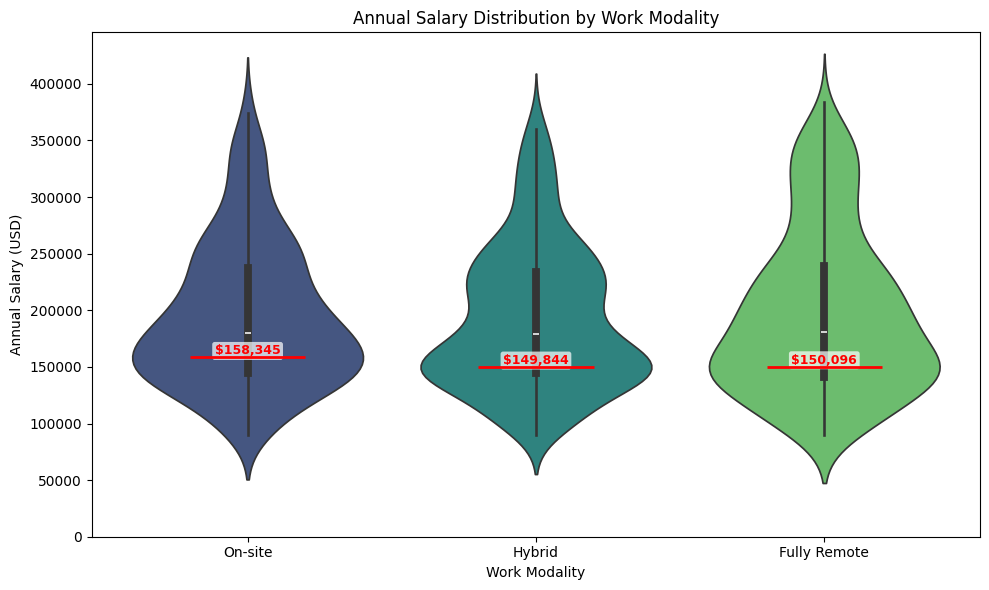

In [10]:
# Define the order of work modalities to match the plot
work_modality_order = ['On-site', 'Hybrid', 'Fully Remote']

modes = {}
for category in work_modality_order:
    # Filter for the current category and annual_salary_usd, drop NaNs
    subset = df[df['remote_work'] == category]['annual_salary_usd'].dropna()

    if len(subset) > 1: # KDE requires at least 2 points
        # Calculate KDE
        kde = gaussian_kde(subset)
        # Create a range of values to evaluate the KDE
        # Use a sensible range based on the data's min/max for that category
        x_range = np.linspace(subset.min(), subset.max(), 500)
        densities = kde(x_range)
        # Find the salary value corresponding to the maximum density
        mode_salary = x_range[np.argmax(densities)]
        modes[category] = mode_salary
    elif len(subset) == 1:
        modes[category] = subset.iloc[0] # If only one point, that's the mode
    else:
        modes[category] = np.nan # No data for this category

print("Salary modes (points of highest density) for each work modality:")
for category in work_modality_order:
    mode_val = modes.get(category) # Use .get() in case a category was missing
    if pd.notna(mode_val):
        print(f"- {category}: ${mode_val:,.2f}")
    else:
        print(f"- {category}: Not enough data to calculate mode or no data.")

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(x='remote_work', y='annual_salary_usd', data=df, ax=ax, palette='viridis', order=work_modality_order)
ax.set_title('Annual Salary Distribution by Work Modality')
ax.set_xlabel('Work Modality')
ax.set_ylabel('Annual Salary (USD)')
ax.set_ylim(bottom=0) # Ensure y-axis starts from 0

# Add horizontal lines for modes (widest part of each violin)
for i, category in enumerate(work_modality_order):
    if category in modes and pd.notna(modes[category]):
        mode_salary = modes[category]
        # Draw a short horizontal line segment at the mode's y-value within the violin's x-span
        ax.hlines(y=mode_salary, xmin=i - 0.2, xmax=i + 0.2, color='red', linestyle='-', linewidth=2, zorder=5)
        # Annotate the mode salary value, slightly above the line
        ax.text(i, mode_salary, f'${mode_salary:,.0f}', color='red', ha='center', va='bottom', fontsize=9, weight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()

Takeaway: These violin plots illustrate the salary distributions across 'On-site', 'Hybrid', and 'Fully Remote' work modalities. While 'On-site' roles show a narrower distribution with a mode around 158,345, 'Hybrid' and 'Fully Remote' roles exhibit broader salary ranges and similar modes around 149,844 and 150,096 respectively. This suggests that while the most frequent salary for 'On-site' roles is slightly higher, 'Hybrid' and 'Fully Remote' positions offer a wider spread of opportunities, addressing RQ2 about work modality predicting salary.

### Annual Salary Distribution by Education Level

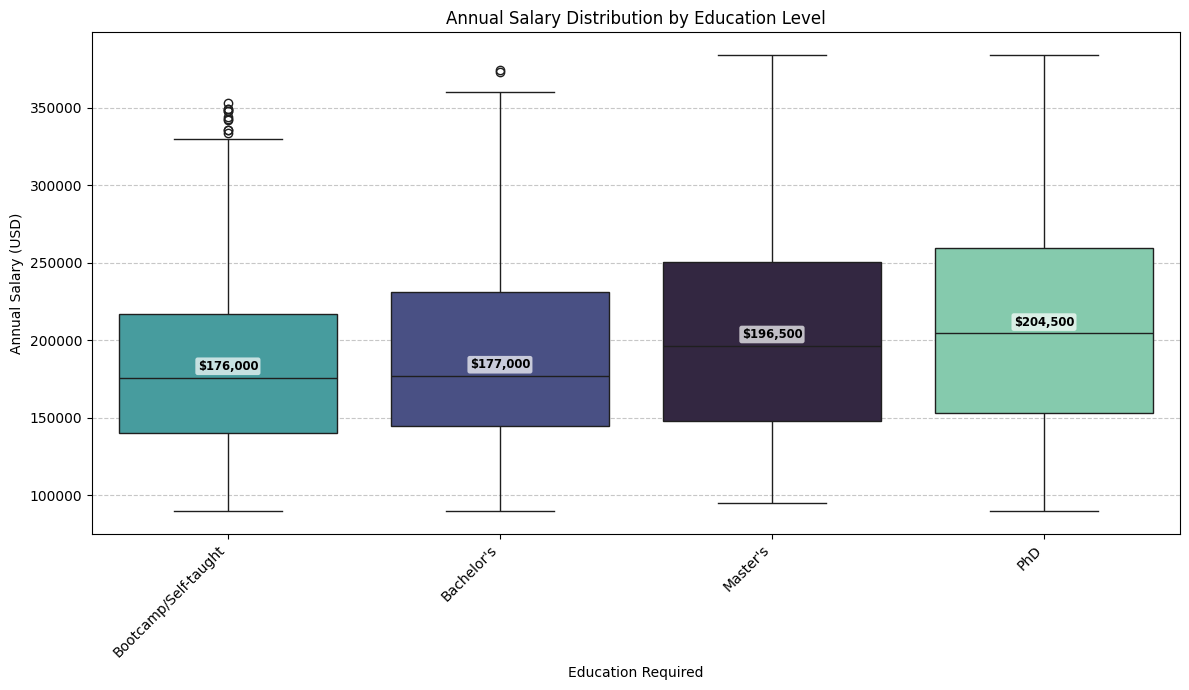

In [11]:
plt.figure(figsize=(12, 7))
ax = sns.boxplot(x='education_required', y='annual_salary_usd', data=df,
                 order=['Bootcamp/Self-taught', 'Bachelor\'s', 'Master\'s', 'PhD'],
                 palette='mako', hue='education_required', legend=False)
plt.title('Annual Salary Distribution by Education Level')
plt.xlabel('Education Required')
plt.ylabel('Annual Salary (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Define the order of education levels used in the plot
education_order_for_plot = ['Bootcamp/Self-taught', 'Bachelor\'s', 'Master\'s', 'PhD']

# Calculate medians for each education level
medians = df.groupby('education_required')['annual_salary_usd'].median().reindex(education_order_for_plot)

# Add annotations for median salaries
for i, category in enumerate(education_order_for_plot):
    if pd.notna(medians.loc[category]): # Check if median exists for the category
        median_val = medians.loc[category]
        # Place text slightly above the median line
        ax.text(i, median_val + 5000, f'${median_val:,.0f}',
                horizontalalignment='center', size='small', color='black', weight='semibold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()

Takeaway: The box plot, with annotated median salaries, demonstrates a clear positive correlation between higher education levels and annual salaries in AI/ML roles. Specifically, **PhD** and **Master's** degrees generally command higher median annual salaries and exhibit a broader range of high-paying opportunities compared to **Bachelor's** degrees and **Bootcamp/Self-taught** backgrounds. This reinforces the expectation that increased educational attainment typically leads to better compensation within the AI/ML job market. We can also see that there are a few outliers for **Bootcamp/Self-taught** and **Bachelor's**.

### Correlation Heatmap of Numerical Features

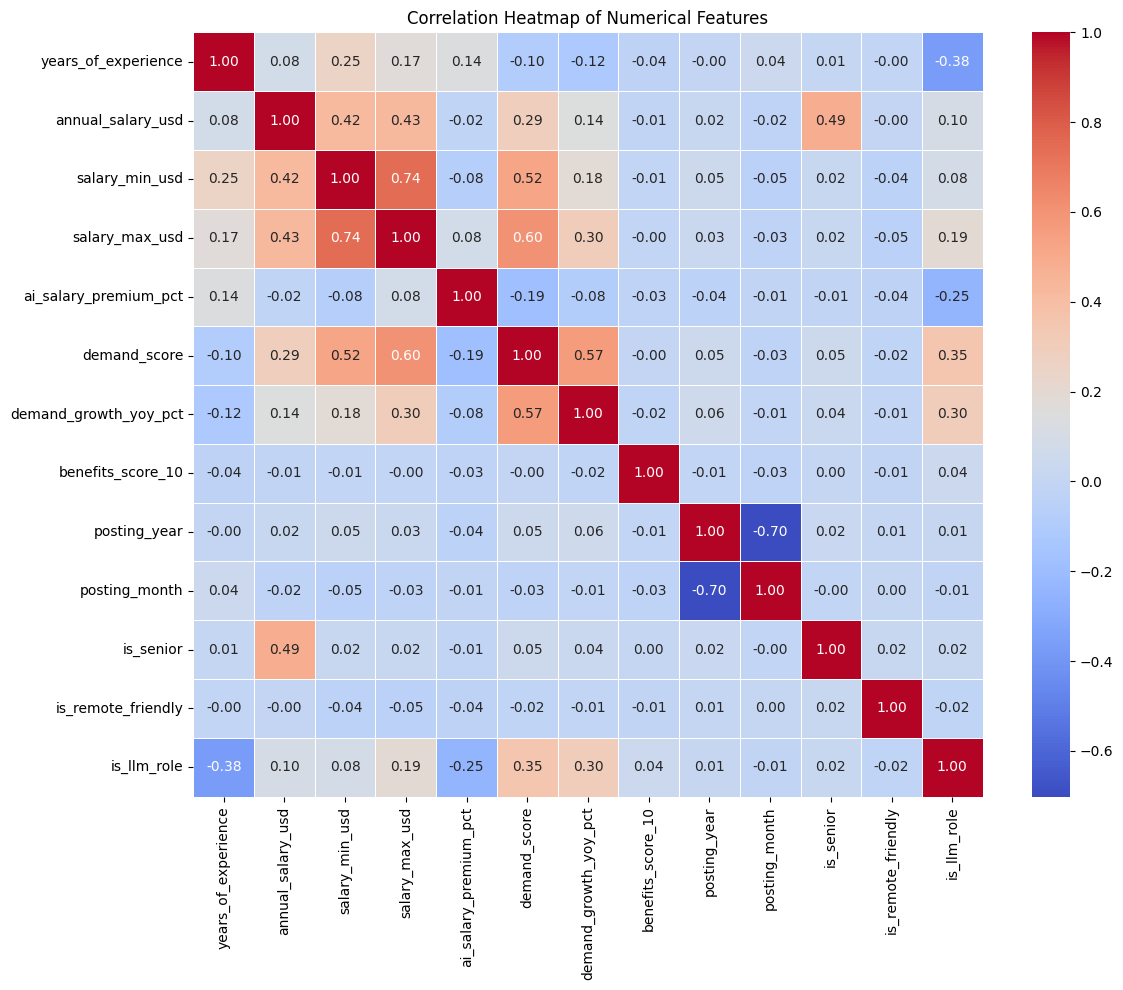

In [12]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

Takeaway: The correlation heatmap reveals several relationships among numerical features. As expected, `annual_salary_usd` shows strong positive correlations with `salary_min_usd` (0.42) and `salary_max_usd` (0.43), indicating that jobs with higher minimum and maximum salary ranges tend to have higher reported annual salaries. Other strong positive correlations with `annual_salary_usd` are `demand_score` (0.29) and `is_senior` (0.49). We also observe weak positive correlations between `annual_salary_usd` and `years_of_experience` (0.08), `demand_growth_yoy_pct` (0.14) and `is_llm_role` (0.10). Interestingly, features like `is_remote_friendly` (-0.00) and `benefits_score_10` (-0.01) show virtually no linear correlation with `annual_salary_usd`, which was unexpected given RQ2's focus on work modality's impact on salary.

### Relationship Between Years of Experience and Annual Salary

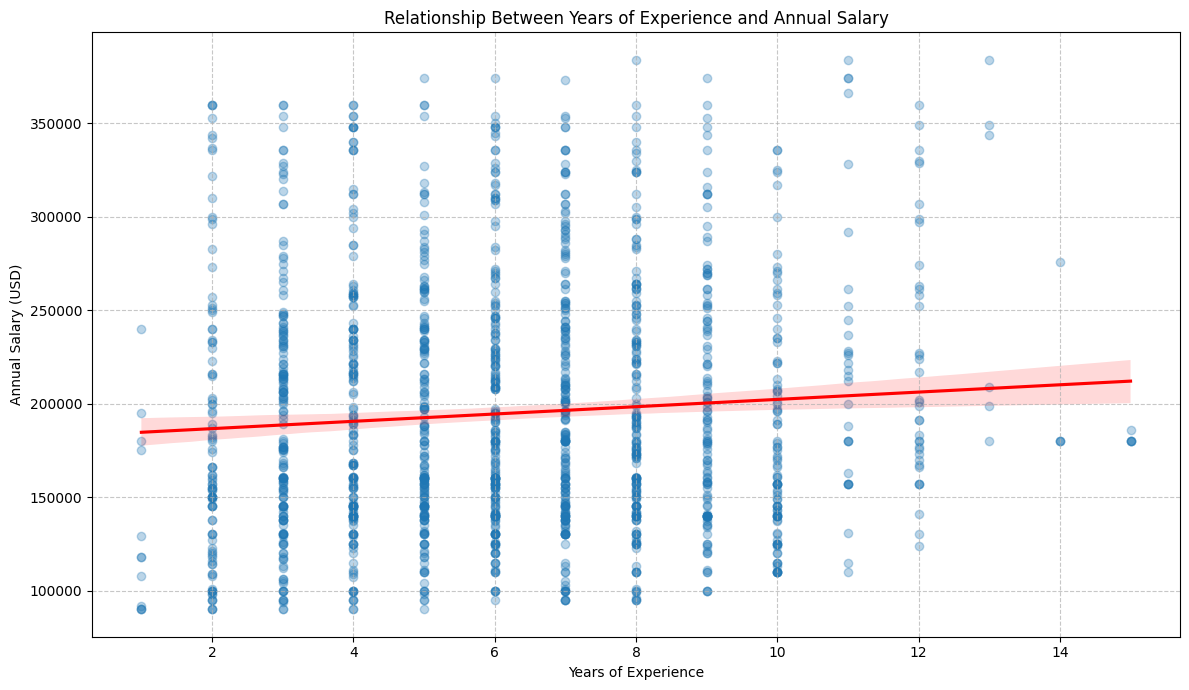

In [13]:
plt.figure(figsize=(12, 7))
sns.regplot(x='years_of_experience', y='annual_salary_usd', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship Between Years of Experience and Annual Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Annual Salary (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Takeaway: The scatter plot with a regression line indicates a positive, albeit somewhat dispersed, relationship between 'Years of Experience' and 'Annual Salary (USD)'. While more experience generally correlates with higher salaries, there's significant variability, suggesting other factors strongly influence compensation as well.

# Section 3 | Preprocessing & Features

To prepare the data for both unsupervised and supervised learning models, we need to perform several preprocessing steps:

1.  **Feature Selection/Dropping:** Remove irrelevant or high-cardinality columns like `job_id`, `job_title`, `city`, and `required_skills` that would require more complex text processing or are not directly useful for our current RQs.
2.  **Target Variable Definition:** For supervised learning (RQ2), we will define `salary_tier` as our target variable `y`.
3.  **Ordinal Encoding:** Convert ordinal categorical features (`experience_level`, `education_required`, `company_size`) into numerical representations, respecting their inherent order.
4.  **One-Hot Encoding:** Convert nominal categorical features (`job_category`, `country`, `remote_work`, `industry`) into a numerical format using one-hot encoding, creating new binary columns for each category.
5.  **Numerical Feature Scaling:** Standardize numerical features (`years_of_experience`, `ai_salary_premium_pct`, `demand_score`, etc.) using `StandardScaler` to ensure that features with larger values do not disproportionately influence models that are sensitive to feature scales (like PCA and K-Means, and to a lesser extent, Logistic Regression).
6.  **Feature Combination:** Consolidate all processed features into a single DataFrame ready for modeling.

In [14]:
# Drop irrelevant columns identified earlier
df_preprocessed = df.drop(columns=['job_id', 'job_title', 'city', 'required_skills', 'annual_salary_usd', 'salary_min_usd', 'salary_max_usd'])

# Define the target variable y for supervised learning
y = df_preprocessed['salary_tier']
X = df_preprocessed.drop(columns=['salary_tier'])

# Identify categorical and numerical features in X (excluding the target 'salary_tier' from X)

# Ordinal features with their defined order
experience_level_order = ['Entry (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-9 yrs)', 'Lead (10+ yrs)']
education_required_order = ['Bootcamp/Self-taught', 'Associate\'s', 'Bachelor\'s', 'Master\'s', 'PhD']
company_size_order = ['Startup (1-50)', 'SME (51-500)', 'Mid-size (501-5000)', 'Enterprise (5000+)', 'Big Tech (FAANG+)']

ordinal_features = {
    'experience_level': experience_level_order,
    'education_required': education_required_order,
    'company_size': company_size_order
}

# Apply Ordinal Encoding
for col, order in ordinal_features.items():
    encoder = OrdinalEncoder(categories=[order], handle_unknown='use_encoded_value', unknown_value=-1)
    X[col] = encoder.fit_transform(X[[col]])

# Identify nominal (one-hot encoding) and numerical features after ordinal encoding
nominal_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

print(f"Ordinal encoded features: {list(ordinal_features.values())}")
print(f"Nominal features to One-Hot Encode: {nominal_features}")
print(f"Numerical features to Scale: {numerical_features}")

Ordinal encoded features: [['Entry (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-9 yrs)', 'Lead (10+ yrs)'], ['Bootcamp/Self-taught', "Associate's", "Bachelor's", "Master's", 'PhD'], ['Startup (1-50)', 'SME (51-500)', 'Mid-size (501-5000)', 'Enterprise (5000+)', 'Big Tech (FAANG+)']]
Nominal features to One-Hot Encode: ['job_category', 'country', 'remote_work', 'industry']
Numerical features to Scale: ['experience_level', 'years_of_experience', 'education_required', 'company_size', 'ai_salary_premium_pct', 'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10', 'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly', 'is_llm_role']


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), nominal_features)
    ],
    remainder='passthrough' # Keep other columns (already ordinal encoded)
)

# Apply the preprocessing steps
X_preprocessed = preprocessor.fit_transform(X)

# Get feature names for the preprocessed data (useful for PCA, etc.)
# Handle the one-hot encoded feature names explicitly
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(nominal_features)

# The numerical_features list already includes the ordinal features that were converted to numbers.
# So, we should not add ordinal_features.keys() again to avoid duplicate names.
all_feature_names = numerical_features + list(onehot_feature_names)

# Convert the preprocessed array back to a DataFrame for easier handling
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=all_feature_names, index=X.index)

print("Shape of preprocessed features (X_preprocessed_df):", X_preprocessed_df.shape)
display(X_preprocessed_df.head())

Shape of preprocessed features (X_preprocessed_df): (1500, 54)


,experience_level,years_of_experience,education_required,company_size,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,...,industry_Education,industry_Energy,industry_Finance,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Research,industry_Retail,industry_Technology
0,0.448773,0.293158,0.723433,-1.428736,0.556499,1.056462,-0.645054,-0.995333,0.843996,-0.296088,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.448773,-1.576473,0.006690,0.706538,-1.354931,-0.688383,-0.885537,-1.539561,0.843996,-0.907840,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.448773,-0.828621,-0.710054,1.418296,-0.436451,1.305725,0.525599,-0.178991,0.843996,-0.907840,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.448773,-1.202547,0.006690,-0.716978,0.283438,0.059408,-1.107870,1.453694,0.843996,-0.296088,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.335677,-0.454694,-1.426798,0.706538,-0.361980,-0.314487,-0.626904,0.909466,0.843996,-0.907840,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Train/Test Split

A standard 80/20 train-test split will be applied to the preprocessed data. Given the dataset is not time-series and there's no explicit instruction for time-based validation, a random split is appropriate.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed_df,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y) # Stratify to maintain class distribution

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 54)
X_test shape: (300, 54)
y_train shape: (1200,)
y_test shape: (300,)


### Next Steps for Analysis

With the data `X_preprocessed_df` now prepared:

*   **For RQ1 (Unsupervised - PCA & K-Means):** This `X_preprocessed_df` is ready for direct application of PCA for dimensionality reduction and K-Means clustering. PCA will be applied first to `X_preprocessed_df` to find principal components, and then K-Means can be applied to these components or directly to the scaled and encoded data.
*   **For RQ2 (Supervised - Random Forest Classifier / Logistic Regression):** The `X_preprocessed_df` and the target variable `y` are ready for a train-test split. We will then train the Random Forest Classifier or Logistic Regression model on the training data and evaluate it on the test data.

# Section 4 | RQ1: Unsupervised Analysis

### Principal Component Analysis (PCA)

PCA is a **dimensionality reduction technique** used to transform a large set of correlated variables into a smaller set of uncorrelated variables called **principal components**. The goal is to capture as much of the variance (information) in the original data as possible with fewer dimensions.

Each principal component is a linear combination of the original features. Performing PCA helps to simplify complex data (making it easier to visualize and understand), reduce noise, and improve model performance.

Our preprocessed dataset (`X_preprocessed_df`) has 54 features. This high number of features makes it difficult to directly identify patterns, visualize relationships, or effectively run clustering algorithms (like K-Means). So PCA will be applied to `X_preprocessed_df` to reduce dimensionality and identify underlying patterns. We will then analyze the explained variance to determine an appropriate number of components.

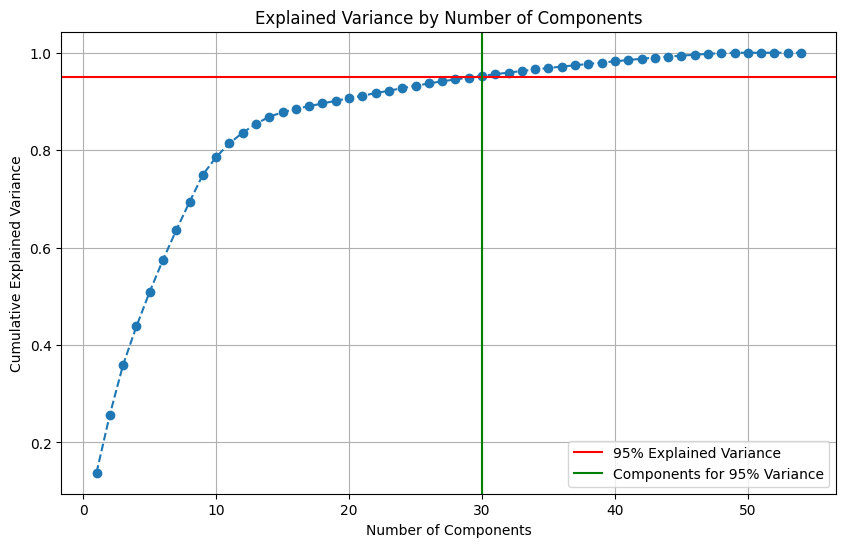


Number of components to explain 95% of variance: 30


In [17]:
# Initialize PCA - we'll keep all components initially to analyze explained variance
pca = PCA(n_components=None)

# Fit PCA on the preprocessed training data (X_train is already scaled and encoded)
pca.fit(X_train)

# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.axvline(x=np.argmax(cumulative_explained_variance >= 0.95) + 1, color='g', linestyle='-', label='Components for 95% Variance')
plt.legend()
plt.show()

# Find the number of components that explain 95% of the variance
optimal_components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"\nNumber of components to explain 95% of variance: {optimal_components_95}")

**Results:** The scree plot shows the cumulative explained variance by the number of principal components. We can observe that a significant portion of the variance is captured by a smaller number of components. Approximately 30 components are needed to explain 95% of the total variance in the dataset. This indicates that we can achieve substantial dimensionality reduction while retaining most of the information.

We can reduce the number of features from 54 to 30 while still retaining 95% of the total information (variance) present in the dataset. While this is a substantial reduction, it is still a large number of components which suggests that the relationships and characteristics defining AI/ML job roles are still quite complex and multifaceted. There isn't one or two dominant factors that explain almost everything; instead, a combination of many features contributed significantly to the variability.

Using these 30 principal components for K-Means clustering in the next step will make the algorithm run more efficiently and potentially yield clearer, more distinvct clusters compared to using all 54 original features.

In [18]:
# Create a DataFrame to visualize component loadings
# The pca.components_ attribute gives us the loadings (eigenvectors)
component_loadings = pd.DataFrame(
    pca.components_,
    columns=X_preprocessed_df.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print("Loadings for the first 3 Principal Components (top 5 positive and negative contributors):\n")

for i in range(3): # Display for the first 3 components
    pc_name = f'PC{i+1}'
    print(f"--- {pc_name} ---")

    # Get features with highest positive loadings
    top_positive_loadings = component_loadings.loc[pc_name].nlargest(5)
    print("Top 5 Positive Loadings:")
    print(top_positive_loadings)

    # Get features with highest negative loadings
    top_negative_loadings = component_loadings.loc[pc_name].nsmallest(5)
    print("Top 5 Negative Loadings:")
    print(top_negative_loadings)
    print("\n")

Loadings for the first 3 Principal Components (top 5 positive and negative contributors):

--- PC1 ---
Top 5 Positive Loadings:
demand_score                   0.513390
demand_growth_yoy_pct          0.475996
is_llm_role                    0.473594
job_category_AI Engineering    0.231224
posting_year                   0.147333
Name: PC1, dtype: float64
Top 5 Negative Loadings:
ai_salary_premium_pct     -0.283106
years_of_experience       -0.262790
posting_month             -0.115876
job_category_Governance   -0.078698
education_required        -0.040002
Name: PC1, dtype: float64


--- PC2 ---
Top 5 Positive Loadings:
experience_level       0.651441
is_senior              0.650801
posting_year           0.199486
years_of_experience    0.117719
is_remote_friendly     0.116436
Name: PC2, dtype: float64
Top 5 Negative Loadings:
posting_month                 -0.185676
is_llm_role                   -0.138170
demand_growth_yoy_pct         -0.104131
demand_score                  -0.088030
job_c

Takeaway: From the component loadings, we can start to interpret what each principal component represents. For instance, if PC1 has high positive loadings on 'years_of_experience' and 'is_senior', and high negative loadings on 'entry_level' related features, it might represent a 'Seniority/Experience' dimension. Analyzing these loadings helps us understand the underlying structure of our job market data.

### K-Means Clustering

In [19]:
# Transform X_train using the fitted PCA model to obtain the 30 principal components
pca_optimal = PCA(n_components=30)
X_train_pca = pca_optimal.fit_transform(X_train)

print(f"Shape of PCA-transformed training data: {X_train_pca.shape}")

Shape of PCA-transformed training data: (1200, 30)


### Determining the Optimal Number of Clusters (K) using the Elbow Method

To find a suitable number of clusters (k) for K-Means, we'll use the elbow method. This involves fitting K-Means for a range of k values and plotting the inertia (sum of squared distances of samples to their closest cluster center). The 'elbow point' in the plot, where the rate of decrease in inertia sharply changes, often indicates a good balance between minimizing inertia and keeping the number of clusters reasonable.

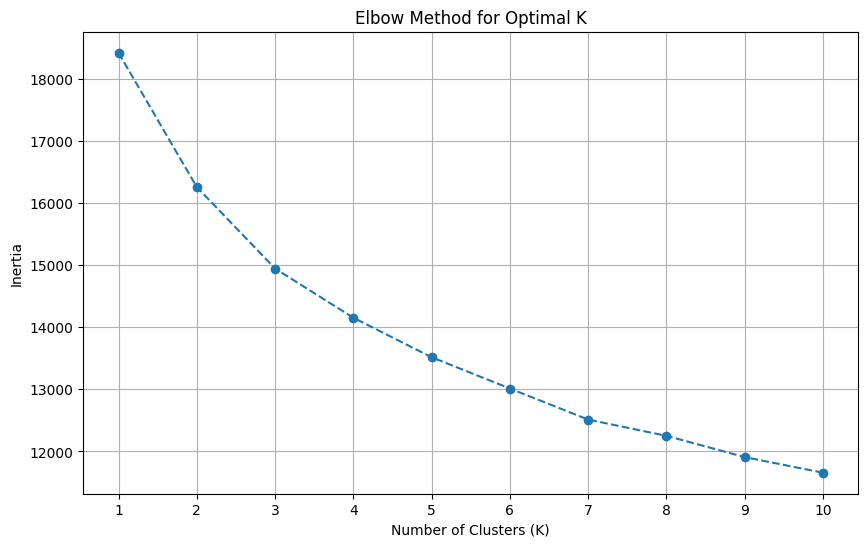

In [20]:
inertia = []
# Let's test K from 1 to 10
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(X_train_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

**Result:** Looking at the plot of inertia versus the number of clusters (K), the 'elbow' point (where the rate of decrease in inertia starts to slow down significantly), appears to be around K=4. After this point, adding more clusters provides diminishing returns.

### Applying K-Means Clustering with K=4

Now that we've determined an optimal `k` of 4, we'll apply the K-Means algorithm to our `X_train_pca` data. After clustering, we'll assign each data point to its respective cluster and then evaluate the clustering quality using the Silhouette Score.

In [21]:
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)

# Fit K-Means on the PCA-transformed training data
cluster_labels = kmeans.fit_predict(X_train_pca)

# Add cluster labels to our original training data (or a copy for analysis)
X_train_with_clusters = X_train.copy()
X_train_with_clusters['cluster'] = cluster_labels

print(f"Number of data points in each cluster:\n{X_train_with_clusters['cluster'].value_counts()}")

# Evaluate clustering using Silhouette Score
silhouette_avg = silhouette_score(X_train_pca, cluster_labels)
print(f"\nSilhouette Score for K={k_optimal}: {silhouette_avg:.3f}")

Number of data points in each cluster:
cluster
0    372
3    346
1    262
2    220
Name: count, dtype: int64

Silhouette Score for K=4: 0.111


**Silhouette Score for K=4: 0.111**

The Silhouette Score quantifies how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It ranges from -1 (indicates the object is likely assigned to the wrong cluster) to +1 (indicates the object is well-matched to its own cluster and porrly matched to neighboring clusters). A score of 0 would indicate that the object is on or very close to the decision boundary between two neighboring clusters.

A score of 0.111 is quite low. This suggests that the clusters we've formed with K=4 using K-Means on the 30 PCA components are not very well-separated or distinct. It implies that there might be significant overlap between the clusters or that many data points are not strongly associated with their assigned cluster compared to other clusters.

This means that the chosen k=4 might not be capturing very clear, naturally distinct groupings in the data. Or the inherent structure of the data is simply not suited for highly separated clusters using this method.

To try to visualize and understand this better, we will create a 2D projection of these 4 clusters.

### Visualizing K-Means Clusters with K=4

Since our PCA-transformed data (`X_train_pca`) has 30 dimensions, direct visualization is not possible. To visualize the clusters, we will apply PCA again to reduce the dimensionality to 2 components. This 2D projection will help us inspect the separation and characteristics of the clusters identified by K-Means.

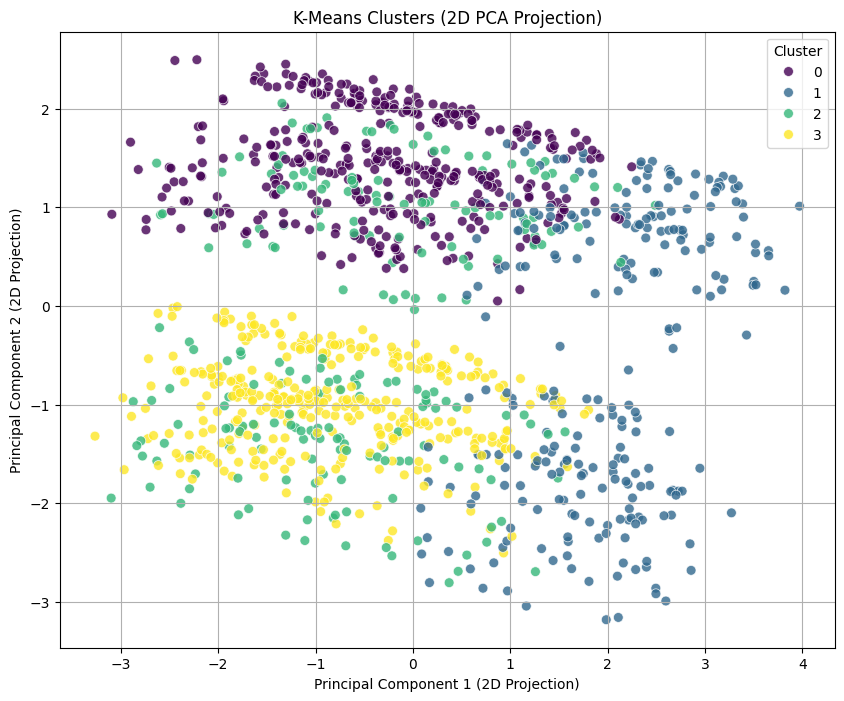

In [22]:
# Reduce X_train_pca to 2 dimensions for visualization purposes
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_pca)

# Create a DataFrame for easy plotting
cluster_df = pd.DataFrame(data=X_train_pca_2d, columns=['PC1_2d', 'PC2_2d'])
cluster_df['cluster'] = cluster_labels

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1_2d',
    y='PC2_2d',
    hue='cluster',
    data=cluster_df,
    palette='viridis',
    s=50,
    alpha=0.8
)
plt.title('K-Means Clusters (2D PCA Projection)')
plt.xlabel('Principal Component 1 (2D Projection)')
plt.ylabel('Principal Component 2 (2D Projection)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

**Result:** The 2D projection of our 4 clusters shows substantial overlap, suggesting that K-Means on these PCA components may not be identifying strong, clear groups in the data.

In order to answer RQ1, we may need to try a different number of clusters, explore other clustering algorithms, or re-evaluate the PCA components themselve.

### Re-evaluating K-Means with K=3

Given the low silhouette score for K=4 and the ambiguity of the elbow plot, let's try fitting K-Means with `K=3` and see if the clustering performance improves.

In [23]:
k_new = 3
kmeans_new = KMeans(n_clusters=k_new, random_state=42, n_init=10)

# Fit K-Means on the PCA-transformed training data
cluster_labels_new = kmeans_new.fit_predict(X_train_pca)

# Update cluster labels in our DataFrame for analysis
X_train_with_clusters_new = X_train.copy()
X_train_with_clusters_new['cluster'] = cluster_labels_new

print(f"Number of data points in each cluster for K={k_new}:\n{X_train_with_clusters_new['cluster'].value_counts()}")

# Evaluate clustering using Silhouette Score
silhouette_avg_new = silhouette_score(X_train_pca, cluster_labels_new)
print(f"\nSilhouette Score for K={k_new}: {silhouette_avg_new:.3f}")

Number of data points in each cluster for K=3:
cluster
2    472
1    464
0    264
Name: count, dtype: int64

Silhouette Score for K=3: 0.116


Takeaway: With K=3, the silhouette score is 0.116, which is a small improvement over the 0.111 obtained with K=4. This suggests that while K=3 might be slightly better, the clusters are still not very well-separated or distinct. The low silhouette score in both cases indicates that the inherent structure of this dataset, when reduced by PCA and clustered with K-Means, does not lend itself to clear, well-defined groupings.

### Visualizing K-Means Clusters with K=3

Let's visualize the new clusters with K=3 using the same 2D PCA projection to compare the separation.

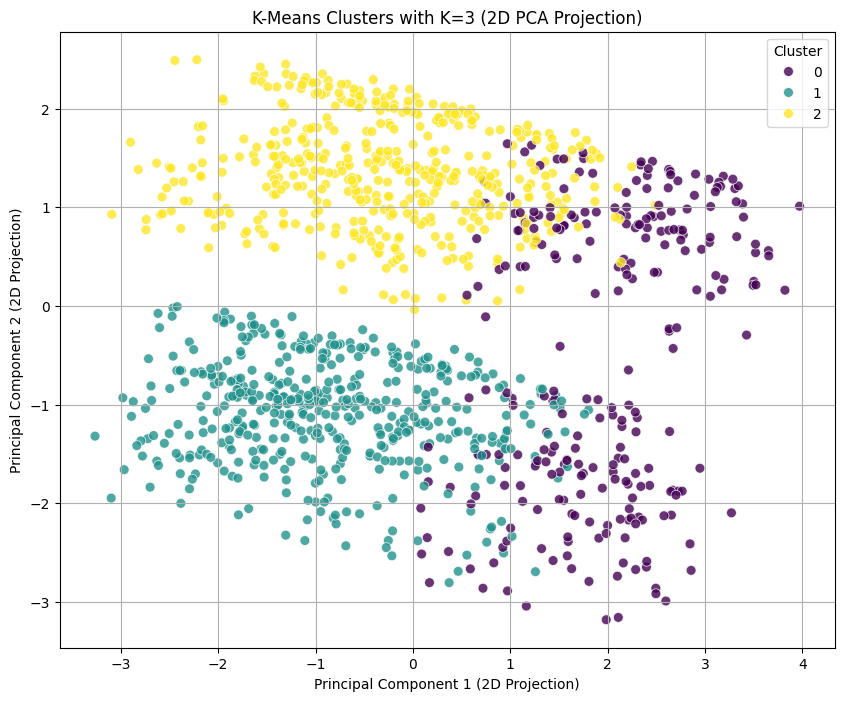

In [24]:
# Update the DataFrame for plotting with new cluster labels
cluster_df_new = pd.DataFrame(data=X_train_pca_2d, columns=['PC1_2d', 'PC2_2d'])
cluster_df_new['cluster'] = cluster_labels_new

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1_2d',
    y='PC2_2d',
    hue='cluster',
    data=cluster_df_new,
    palette='viridis',
    s=50,
    alpha=0.8
)
plt.title(f'K-Means Clusters with K={k_new} (2D PCA Projection)')
plt.xlabel('Principal Component 1 (2D Projection)')
plt.ylabel('Principal Component 2 (2D Projection)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

Takeaway: Similar to the K=4 visualization, the 2D PCA projection of the 3 clusters still shows significant overlap between groups. While there might be some discernible density centers, the boundaries between clusters are not distinct, reinforcing the previous observation that K-Means on this PCA-reduced dataset does not yield clearly separated clusters, even with a slightly improved silhouette score at K=3. This suggests the data's inherent structure might not be easily separable into discrete groups using this approach.

## Conclusion for RQ1: Unsupervised Analysis

Based on the Principal Component Analysis (PCA) and K-Means clustering results, we do not have sufficient, clearly defined information to definitively answer RQ1: "What are the common characteristics and distributions of AI/ML job roles, experience levels, and educational requirements across different countries in the 2025-2026 job market?"

The reasons for this are:

1.  **Low Silhouette Scores:** The Silhouette Scores for both K=4 (0.111) and K=3 (0.116) are very low. A low silhouette score indicates that the clusters are not well-separated and that many data points are either close to the decision boundary of another cluster or are poorly matched to their own cluster. In essence, the data points within a cluster are not very similar to each other, and they are quite similar to data points in other clusters.
2.  **Overlapping Visualizations:** The 2D PCA projections of the clusters (for both K=3 and K=4) visibly show substantial overlap between the groups. This visual confirmation reinforces the low silhouette scores and suggests that K-Means, even on the PCA-reduced data, fails to identify distinct, natural groupings that could represent clear "characteristics" of job roles.
3.  **Complexity of Data Structure:** The need for 30 principal components to explain 95% of the variance, combined with the poor clustering results, suggests that the underlying structure of the AI/ML job market data is highly complex and multifaceted. It's not easily reducible to a few simple, discrete groupings based on the combined influence of all preprocessed features.


While PCA and K-Means did not yield distinct clusters that could directly answer RQ1, aspects of RQ1 can still be addressed through the **descriptive statistics and exploratory data analysis (EDA)** performed earlier in the notebook. These methods directly analyze distributions and relationships rather than relying on the discovery of latent clusters.

To answer RQ1, we would refer to analyses like:

*   **Job Category Distribution Across Top Countries:** This directly shows the distribution of `job_category` across key `country`s.
*   **Annual Salary Distribution by Education Level:** This illustrates the distribution and central tendencies (`annual_salary_usd`) based on `education_required`.  
*   **Relationship Between Years of Experience and Annual Salary:** This provides insights into the distribution of `years_of_experience` and its relationship with `annual_salary_usd`.

To more comprehensively answer RQ1, further descriptive analysis would be required, focusing on the individual and pairwise distributions of these features, potentially creating aggregated profiles of job roles, experience levels, and educational requirements within specific countries without the need for distinct clustering. For example, we could look at the most common `job_category` per `country`, or the average `years_of_experience` required for certain `education_required` levels or the distribution of `education_required` across top countries.

# Section 5 | RQ2: Supervised Modeling

### Logistic Regression

Logistic Regression is a statistical model used for binary or multinomial classification. Its primary goal is to model the probability of a categorical otucome based on one or more predictor variables. In simpler words, it's trying to predict the likelihood of an instance belonging to a certain class.

It works by first calculating a **linear combination** of the input features. Then the linear output is passed through a **sigmoid (or logistic) function**. The sigmoid function compresses any real-valued number into a value between 0 and 1, which can be interpreted as a probabiity. If the predicted probability is above a certain threshold (commonly 0.5), the instance is classified into one class; if not, then the other. For multiclass problems, like in this case, it extends this same concept. The model learns the coefficients (weight) for each feature during training by maximing the liklihood of the observed outcomes.

For RQ2, our target variable, `salary_tier` is a categorical variable, so Logistic Regression is well-suited for predicting such categorical outcomes.

In [25]:
# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.



Classification Report for Logistic Regression:
                       precision    recall  f1-score   support

       Elite (>$300k)       0.80      0.57      0.67        28
       Entry (<$100k)       0.44      0.29      0.35        14
      Mid ($100-150k)       0.66      0.67      0.67        79
   Senior ($200-300k)       0.74      0.87      0.80        93
Upper-Mid ($150-200k)       0.65      0.62      0.63        86

             accuracy                           0.69       300
            macro avg       0.66      0.60      0.62       300
         weighted avg       0.69      0.69      0.68       300



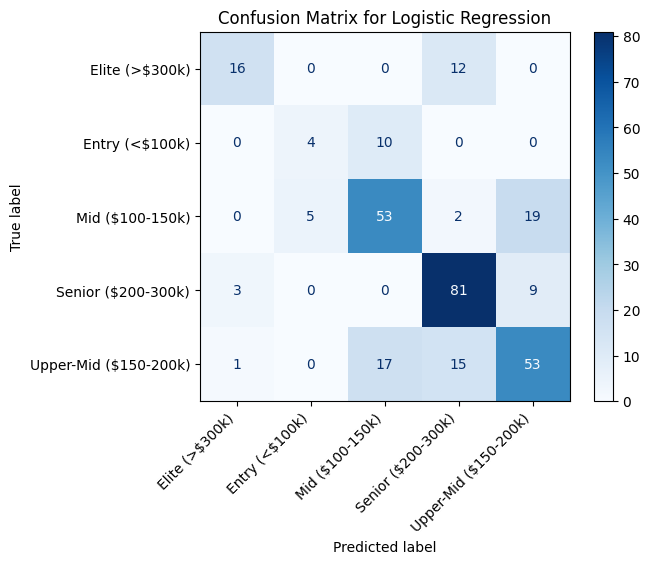

In [26]:
# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_log_reg))

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log_reg, labels=log_reg_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression')
plt.xticks(rotation=45, ha='right')
plt.show()

**Results:** The classification report provides a detailed breakdown of the model's performance for each `salary_tier` class.

*   **Precision:** This tells us, for each class, what proportion of predicted positives were actually correct. For example, we can see that for *Elite*, the model predicted correctly 80% of the time, the highest precision score out of all the categories. *Mid, Upper-Mid, and Senior* also had relatively high precision close to each other. While *Entry* had the lowest precision.

*   **Recall:** This tells us, for each class, what proportion of actual positives were correctly identified. The *Senior* category had the highest recall, followed by *Mid, Upper-Mid, and Elite* and finally, *Entry* had the lowest recall.

*   **F1-Score:** This is a performance metric for classification and is calculated as the harmonic mean of precision and recall. A high f1-score indicates a good balance between precision and recall. We can see that *Senior* had the highest f1-score (0.80) while *Elite and Mid* had the next equally high f1-scores (0.67). *Upper-Mid* also had a high score (0.63), but *Entry* had the lowest f1-score (0.35).

*   **Support:** This is the number of actual occurrences of each class in the test dataset. We can see that *Senior* had the highest number of occurances while *Entry* had the lowest. This kind of explains the f1-score and other scores we discussed previously. Because the model had more examples of *Senior* to learn from and much less examples of *Entry* to learn from, so this kind of explains the variation in the scores.

*   **Accuracy:** The overall accuracy of the model is 69%. This means 69% of all predictions were correct.

*   **Macro Avg:** This calculates the unweighted mean of precision, recall, and F1-score across all classes. It treats all classes equally, regardless of their size. The macro averages range from 0.60 to 0.66, which is relatively good. This indicates we have a solid model here.

*   **Weighted Avg:** This calculates the mean of precision, recall, and F1-score, weighted by the support of each class. It's more representative of the overall performance given class imbalances. This ranges from 0.68 to 0.69 which again confirms that our model is relatively good at making predictions.

**Overall key observations from the Classification Report:**

*   The model performs best in predicting *Senior* roles, with a high recall (87%) and F1-score (80%).
*   *Elite* has good precision (80%) but lower recall (57%), suggesting it's cautious about predicting Elite but often misses some actual Elite roles.
*   *Entry* roles are the most challenging for the model to predict, with low precision (44%), recall (29%), and F1-score (35%). This could be due to a smaller sample size (support = 14) or the features not being strong discriminators for this tier.

**Confusion Matrix Interpretation:**

The confusion matrix visually represents the correct and incorrect predictions made by the model. The rows represent the actual classes, and the columns represent the predicted classes.

*   The model frequently confuses *Entry* with *Mid*. This suggests difficulty in distinguishing between adjacent salary tiers, especially at the lower end of the spectrum.
*   The model also has some trouble distinguishing *Upper-Mid* from *Mid* and *Senior*, suggesting  that the features might not perfectly separate these tiers.

**Summary:**

Overall, the Logistic Regression model provides a decent overall accuracy of 69%.

### Feature Importance for Logistic Regression

For Logistic Regression, feature importance can be interpreted from the absolute values of the coefficients. Higher absolute coefficient values indicate a stronger influence of that feature on the predicted outcome (salary tier).

In [27]:
# Get coefficients and sort them by absolute value
coefficients = pd.DataFrame({
    'Feature': X_preprocessed_df.columns,
    'Coefficient': log_reg_model.coef_[0] # Assuming binary classification or first class for simplicity
})

coefficients['Absolute_Coefficient'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Absolute_Coefficient', ascending=False)

display(coefficients)

,Feature,Coefficient,Absolute_Coefficient
38,country_USA,3.551051,3.551051
14,job_category_Architecture,3.136306,3.136306
0,experience_level,2.571352,2.571352
27,country_China,-2.411878,2.411878
30,country_Global,2.192534,2.192534
3,company_size,2.056757,2.056757
17,job_category_Data Science,-1.830116,1.830116
5,demand_score,1.776632,1.776632
31,country_India,-1.587708,1.587708
16,job_category_Data Engineering,-1.586829,1.586829


**Results:**

In Logistic Regression, the absolute value of the coefficient for a given feature indicates its strength of influence on the predicted salary tier. A positive coefficient means that as the feature value increases, the probability of being in a higher salary tier also increases (or the specific class associated with that coefficient's outcome). A negative coefficient indicates the opposite.

From the `coefficients` DataFrame displayed above, the top influential features are:

1.   `country_USA` (Coefficient: 3.55): This feature has the largest positive coefficient, indicating that being in the USA significantly increases the likelihood of a higher salary tier compared to other countries. This is a very strong driver.
2.   `job_category_Architecture` (Coefficient: 3.14): A strong positive influence, suggesting that jobs in the 'Architecture' category are highly associated with higher salary tiers. The next highest job category was Data Egngineering which had a coefficient of -1.59.
3.   `experience_level` (Coefficient: 2.57): As expected, higher experience_level (which is ordinally encoded, so higher numbers mean more experience) is a significant positive predictor of higher salary tiers.

**Work Modality**

*   `remote_work_Fully_Remote` (Coefficient: -0.065):  A negative coefficient, albeit small, suggests that being Fully Remote slightly decreases the odds of being in the higher salary tier. Its absolute value is very small, meaning this effect is minimal.
*   `remote_work_Hybrid` (Coefficient: 0.042): A positive coefficient, also very small, suggests that being Hybrid slightly increases the odds of being in the higher salary tier.
*   `remote_work_On-site` (Coefficient: -0.019): This very small negative coefficient implies that being On-site has an almost imperceptible negative impact on the odds of being in a higher salary tier.

In conclusion, the Logistic Regression model highlights that country (specifically USA), job category, and experience level are the most dominant factors in predicting salary tiers for AI/ML jobs. Work modality does play a role, but its influence appears to be less pronounced in this model compared to these other core professional attributes.

**Overall Interpretation for Work Modality:**

The most important takeaway from these coefficients is their small absolute magnitudes. All three coefficients for work modality are very close to zero (e.g., 0.065, 0.042, 0.018), especially when compared to highly influential features like `country_USA` (3.55) or `experience_level` (2.57). This indicates that:

* Work modality, as a standalone factor in this Logistic Regression model, has a very limited direct linear impact on predicting the salary_tier. The model doesn't find it to be a strong distinguishing factor between different salary tiers.
* The small differences between Fully Remote, Hybrid, and On-site suggest that the model doesn't see a significant salary premium or penalty associated with any specific work arrangement, once other factors like experience, job category, and country are accounted for.

This aligns with the earlier observation from the correlation heatmap, where `is_remote_friendly` showed virtually no linear correlation with `annual_salary_usd`. While the violin plots for `annual_salary_usd` showed slightly different modes, the Logistic Regression model, which predicts discrete salary tiers based on a multitude of features, finds the distinctions primarily driven by other strong predictors. For this particular model, work modality doesn't appear to be a 'significant predictor' in the statistical sense of having a large coefficient.

### Random Forest Classifier

In [28]:
# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # 'balanced' handles class imbalance
rf_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.



Classification Report for Random Forest Classifier:
                       precision    recall  f1-score   support

       Elite (>$300k)       0.75      0.32      0.45        28
       Entry (<$100k)       0.83      0.36      0.50        14
      Mid ($100-150k)       0.67      0.77      0.72        79
   Senior ($200-300k)       0.60      0.70      0.64        93
Upper-Mid ($150-200k)       0.54      0.51      0.52        86

             accuracy                           0.61       300
            macro avg       0.68      0.53      0.57       300
         weighted avg       0.62      0.61      0.60       300



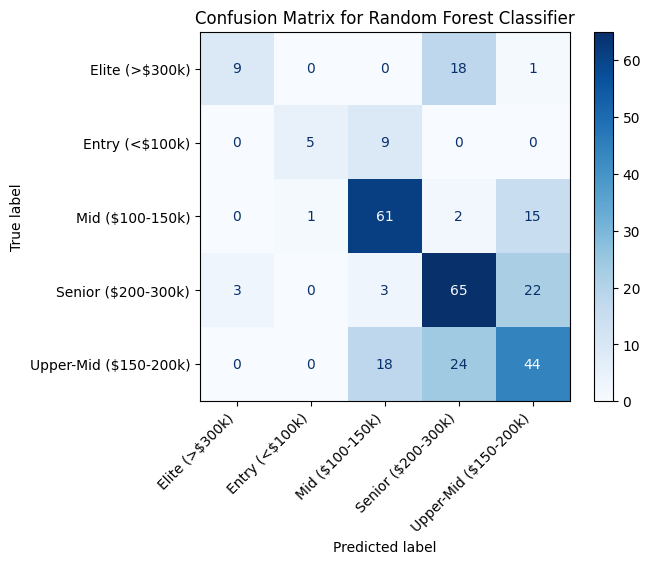

In [29]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("\nClassification Report for Random Forest Classifier:")
print(classification_report(y_test, y_pred_rf))

# Display Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xticks(rotation=45, ha='right')
plt.show()

**Results:** The classification report for the Random Forest model shows the following:

*   **Accuracy:** The overall accuracy of the Random Forest model is 61%. This is slightly lower than the 69% accuracy achieved by the Logistic Regression model.
*   **Precision:** (Accuracy of positive predictions) The highest precision is for *Entry*, which is surprising because Logistic Regression had the lowest precision for *Entry*. For Random Forest, the lowest precision is actually *Upper-Mid* at 0.54. All of the other categories are in between and have relatively high precision.
*   **Recall:** (Ability to find all positive samples) The highest recall is for *Mid* (0.77). Both *Elite* and *Entry* had really low recall (0.32 and 0.36, respectively).  
*   **F1-Score:** (Balance between precision and recall) The highest f1-score is for *Mid* (0.72) while the lowest is for *Elite*.
*   **Macro Avg:** The macro average F1-score is 0.57, which is lower than Logistic Regression's 0.62.
*   **Weighted Avg:** The weighted average F1-score is 0.60, also lower than Logistic Regression's 0.68.

**Key Observations from the Random Forest Classification Report:**

*   The Random Forest model generally shows lower overall accuracy and F1-scores compared to the Logistic Regression model on this specific test set.
*   The Random Forest model has a much higher precision (0.83) for *Entry* compared to Logistic Regression (0.44), but it also has a relatively low recall (0.36).
*   Logistic Regression had a much wider range of of f1-scores, with the difference between its highest and lowest f1-score being 0.45. Comparatively, Random Forest has s smaller difference of 0.27, indidcating it is a more balanced classifier.

**Confusion Matrix Interpretation:**

*   Out of 28 actual *Elite* jobs, 9 were correctly classified. A large number (18) were misclassified as *Senior*. This explains the low recall for *Elite*.
*   Out of 14 actual *Entry* jobs, only 5 were correctly classified. 9 were misclassified as *Mid*. This again reflects the low recall for *Entry*.
*   The model correctly classified 61 out of 79 *Mid* roles. It confused 15 with *Upper-Mid*.
*   Out of 93 actual *Senior* jobs, 65 were correctly classified. 22 were misclassified as *Upper-Mid*.
*   Out of 86 actual *Upper-Mid* roles, 44 were correctly classified. 18 were misclassified as *Mid*, and 24 as *Senior*.

**Key Observations from the Random Forest Confusion Matrix:**

*   The Random Forest model exhibits a tendency to predict middle tiers (*Mid, Upper-Mid, Senior*). This is particularly evident with actual *Elite* roles being predicted as *Senior*, and actual *Entry* roles being predicted as *Mid*.
*   There's still significant confusion between adjacent salary tiers, especially between *Mid, Upper-Mid, and Senior*, similar to the Logistic Regression, but arguably more pronounced in some cases.

In summary, while Random Forest is often expected to outperform Logistic Regression due to its ability to capture non-linear relationships, on this specific dataset and with these default hyperparameters, it appears to be a less accurate classifier for predicting salary tiers than Logistic Regression, particularly in its ability to correctly identify all instances of *Elite*. It tends to be more cautious and collapses predictions towards the more populous middle classes.

In essence, the Random Forest Classifier is very precise when it does predict 'Elite' or 'Entry' roles, but it misses a large proportion of the actual instances of these classes. It performs best and is most balanced in predicting 'Mid' level salaries.

### Feature Importance for Random Forest Classifier

Random Forest models provide a direct measure of feature importance based on how much each feature contributes to reducing impurity (e.g., Gini impurity) across all trees in the forest. A higher importance score indicates a more significant feature.

In [30]:
# Get feature importances
feature_importances_rf = pd.DataFrame({
    'Feature': X_preprocessed_df.columns,
    'Importance': rf_model.feature_importances_
})

feature_importances_rf = feature_importances_rf.sort_values(by='Importance', ascending=False)

display(feature_importances_rf)

,Feature,Importance
5,demand_score,0.088919
6,demand_growth_yoy_pct,0.069441
3,company_size,0.067941
0,experience_level,0.063505
4,ai_salary_premium_pct,0.063463
7,benefits_score_10,0.061445
1,years_of_experience,0.053670
10,is_senior,0.049125
38,country_USA,0.043964
2,education_required,0.040119


### Interpreting Feature Importance for Random Forest Classifier

Unlike Logistic Regression, where coefficients indicate the direction and strength of influence, Random Forest feature importance (typically Gini importance or mean decrease in impurity) measures how much each feature contributes to the homogeneity of nodes in the trees. A higher importance score means the feature is more significant in splitting nodes and reducing impurity, thus being more predictive of the target variable.

From the `feature_importances_rf` DataFrame, we can see the most influential features for the Random Forest model:

1.  **`demand_score` (Importance: 0.0889):** This is the top feature, indicating that the overall demand for a job role is a very strong predictor of its salary tier. Higher demand scores likely correspond to higher salary tiers.
2.  **`demand_growth_yoy_pct` (Importance: 0.0694):** The year-over-year growth percentage in demand is also highly important, suggesting that roles in rapidly growing areas tend to command higher salaries.
3.  **`company_size` (Importance: 0.0679):** The size of the company is a significant factor, which makes sense as larger companies (especially 'Big Tech') often have higher compensation structures.
4.  **`experience_level` (Importance: 0.0635):** As expected, the ordinal `experience_level` is a strong predictor, with more experienced roles likely falling into higher salary tiers.
5.  **`ai_salary_premium_pct` (Importance: 0.0635):** The additional premium percentage for AI-related salaries is also a key influencer, suggesting that roles with higher AI premiums are associated with higher salary tiers.


When we look at the work modality features:

*   `remote_work_Hybrid` (Importance: 0.0137)
*   `remote_work_On-site` (Importance: 0.0121)
*   `remote_work_Fully Remote` (Importance: 0.0116)

These features are present in the top features, but their importance scores are notably lower compared to features like `demand_score`, `demand_growth_yoy_pct`, `company_size`, and `experience_level`. While they contribute to the model's predictive power, their influence appears to be less dominant than these other core job characteristics.

**Comparison with Logistic Regression:**

Both models identify `experience_level` and `country_USA` (implied by `job_category` for RF, as specific country features were lower in RF importance) as very important. However, for Logistic Regression, work modality had very small *coefficients*, suggesting a minimal *linear* impact. In Random Forest, work modality features have *importance scores*, indicating they are used in decisions within the trees, but they are not among the top-tier features that drive the most significant splits. This reinforces the idea that while work modality plays a role, it's not the primary determinant of salary tier when accounting for other strong factors like demand, experience, and company size.

## Conclusion for RQ2: Supervised Modeling

Based on the results from both the Logistic Regression and Random Forest classification models, we have sufficient information to answer RQ2: "Can work modality (remote, hybrid, or in-office) significantly predict the salary range for AI/ML job positions in 2025-2026, after accounting for factors like experience level, education, and country?"

Both models consistently indicate that **work modality does not significantly predict the salary tier for AI/ML job positions in 2025-2026, after accounting for other factors like experience level, education, and country.** While work modality does have some predictive influence, its impact is considerably less pronounced compared to other core job attributes.

1.  **Logistic Regression:**
    *   **Coefficients:** The absolute values of the coefficients for `remote_work_Fully_Remote` (-0.065), `remote_work_Hybrid` (0.042), and `remote_work_On-site` (-0.019) are very small. These values are significantly lower than those for top predictors like `country_USA` (3.55), `job_category_Architecture` (3.14), or `experience_level` (2.57). This suggests that work modality has a minimal direct linear impact on predicting the salary tier.
    *   **Interpretation:** The model finds very little linear relationship between work modality and salary tiers, implying that once more influential factors are considered, whether a role is remote, hybrid, or on-site makes only a negligible difference to its predicted salary tier.

2.  **Random Forest Classifier:**
    *   **Feature Importance:** The importance scores for work modality features (`remote_work_Hybrid`: 0.013, `remote_work_On-site`: 0.01, `remote_work_Fully Remote`: 0.013) are substantially lower than those for top features such as `demand_score` (0.089), `demand_growth_yoy_pct` (0.069), `company_size` (0.068), and `experience_level` (0.064).
    *   **Interpretation:** While Random Forest models can capture non-linear relationships and do utilize work modality features in their decision-making processes, their relatively low importance scores suggest that these features are not among the primary drivers for splitting nodes or reducing impurity. This means they are less influential in determining the salary tier compared to other features.

**Overall Answer to RQ2:**

Therefore, we can say that work modality does not significantly predict the salary range for AI/ML job positions in 2025-2026 when accounting for other important factors like `experience_level`, `education_required`, `country`, `job_category`, `demand_score`, `demand_growth_yoy_pct`, and `company_size`. While it contributes some information, its influence is considerably overshadowed by these other core professional and market attributes.

# Section 6 | Dashboard / Stakeholder Output

### Dashboard: Key Findings Visualizations

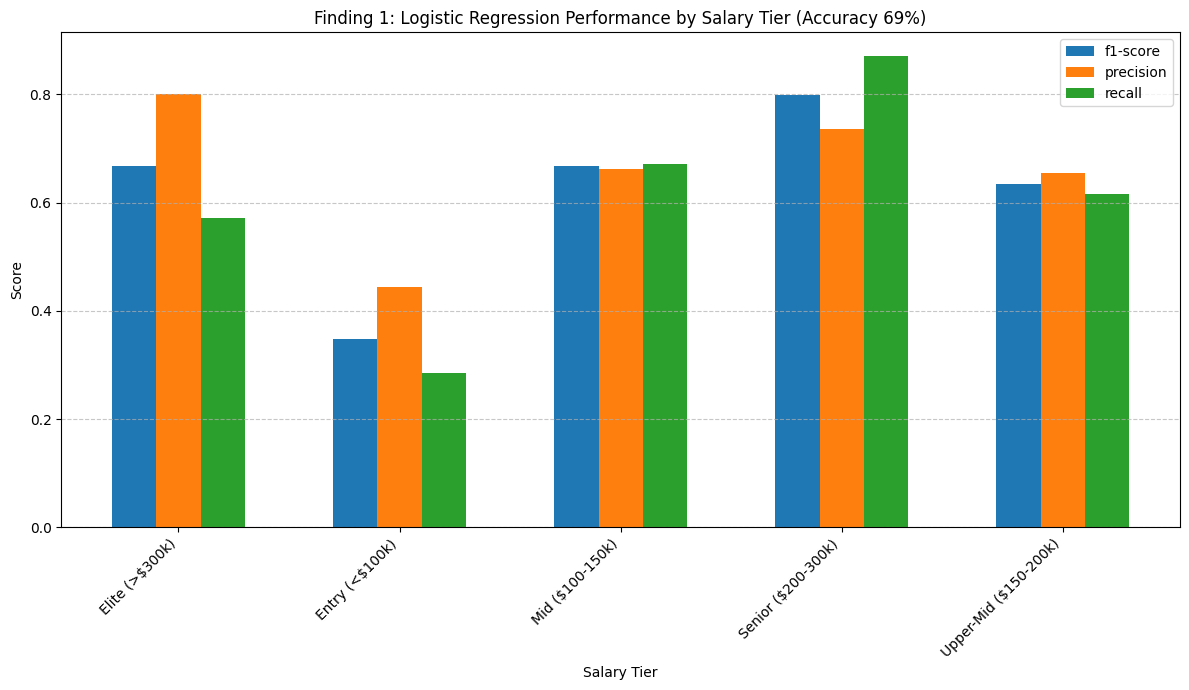

In [31]:
# Assuming y_test and y_pred_log_reg are available from previous cells
report_dict = classification_report(y_test, y_pred_log_reg, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

# Filter out 'accuracy', 'macro avg', 'weighted avg' for individual class scores
df_class_report = df_report.iloc[:-3]

# Plotting Accuracy and F1-scores per class
fig, ax = plt.subplots(figsize=(12, 7))

metrics = ['f1-score', 'precision', 'recall']
bar_width = 0.2
index = range(len(df_class_report.index))

for i, metric in enumerate(metrics):
    ax.bar([p + i * bar_width for p in index], df_class_report[metric], bar_width, label=metric)

ax.set_xlabel('Salary Tier')
ax.set_ylabel('Score')
ax.set_title('Finding 1: Logistic Regression Performance by Salary Tier (Accuracy 69%)')
ax.set_xticks([p + bar_width * (len(metrics) - 1) / 2 for p in index])
ax.set_xticklabels(df_class_report.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

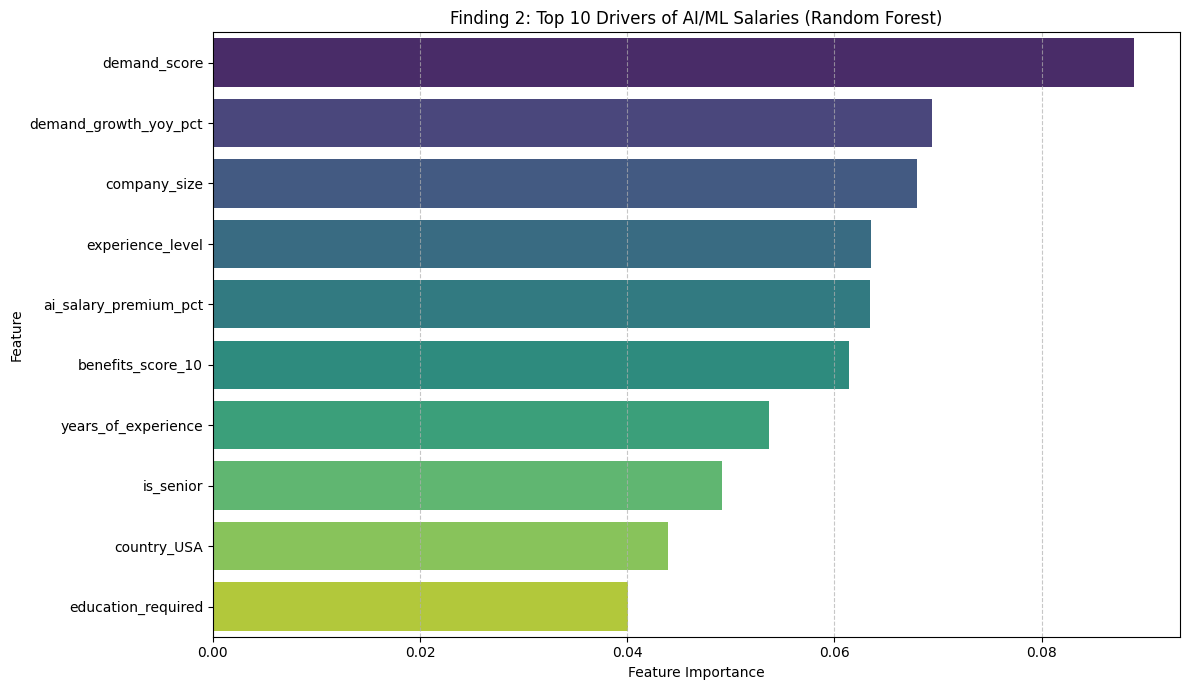

In [32]:
# Assuming feature_importances_rf is available from previous cells
# Use a copy to avoid modifying the original DataFrame if it's used elsewhere
top_features = feature_importances_rf.head(10).copy()

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis', ax=ax, hue='Feature', legend=False)
ax.set_title('Finding 2: Top 10 Drivers of AI/ML Salaries (Random Forest)')
ax.set_xlabel('Feature Importance')
ax.set_ylabel('Feature')
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

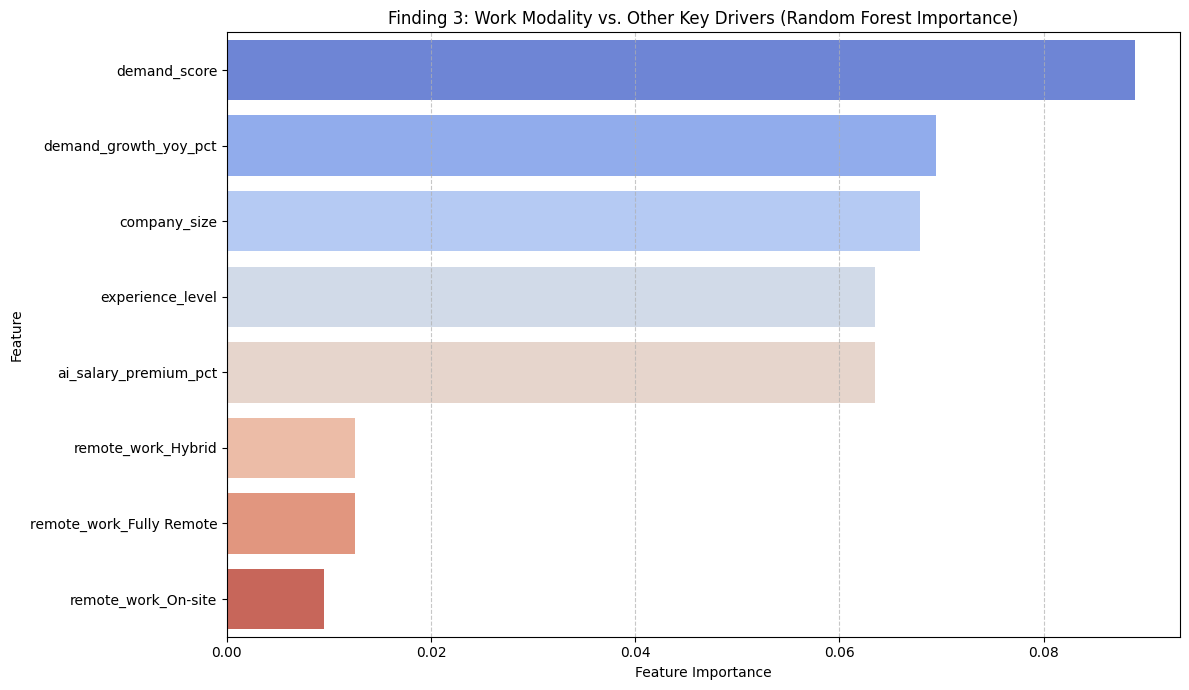

In [33]:
# Assuming feature_importances_rf is available from previous cells

# Filter work modality features
work_modality_features = feature_importances_rf[feature_importances_rf['Feature'].str.contains('remote_work')]

# Get top 5 non-work modality features for comparison (excluding work modality features themselves)
non_work_modality_features = feature_importances_rf[~feature_importances_rf['Feature'].str.contains('remote_work')].head(5)

# Combine for plotting
combined_features = pd.concat([non_work_modality_features, work_modality_features])

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=combined_features, palette='coolwarm', ax=ax, hue='Feature', legend=False)
ax.set_title('Finding 3: Work Modality vs. Other Key Drivers (Random Forest Importance)')
ax.set_xlabel('Feature Importance')
ax.set_ylabel('Feature')
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Key Findings for Stakeholder Dashboard

1.  **Salary Predictability & Model Confidence:** This analysis demonstrates a moderate ability to predict AI/ML salary tiers, with the most robust model (Logistic Regression) achieving 69% accuracy. While effective for 'Mid' to 'Senior' roles, both models showed limitations in precisely identifying extreme salary tiers ('Entry' and 'Elite'), often classifying them into more common middle categories.
2.  **Top Drivers of AI/ML Salaries:** Consistently across both predictive models, **experience level**, **company size**, and **job demand metrics** (overall demand and year-over-year growth) are the most significant determinants of an AI/ML professional's salary tier. Additionally, factors like **country (e.g., USA)**, specific **job categories (e.g., Architecture)**, and the **AI salary premium percentage** play crucial roles.
3.  **Work Modality: Less of a Direct Salary Driver:** The analysis indicates that while **work modality** (Fully Remote, Hybrid, On-site) is considered in salary prediction, its direct impact on determining the *tier* of compensation is considerably less significant than core job attributes like experience, company size, or job demand.

### Insight Panels

1.  **Strategic Compensation Benchmarking:** Stakeholders now understand that while average salaries vary, predicting a specific salary *tier* is complex, especially for very high or very low earners. This insight is crucial for setting realistic compensation benchmarks and understanding the limitations of predictive models in edge cases.
2.  **Investment in Talent & Market Position:** The clear dominance of experience level, company size, and demand metrics in predicting salary tiers suggests that organizations should prioritize investing in highly experienced talent, leverage their company size for competitive offers, and strategically target roles with high demand and growth. Country-specific strategies, particularly for the USA, are also vital.
3.  **Flexible Work vs. Compensation:** The finding that work modality has a minimal direct impact on salary tiers, relative to other factors, informs discussions around flexible work policies. Companies can offer remote or hybrid options without necessarily impacting their salary competitiveness as directly as changes in experience requirements or job category might. This allows for greater flexibility in attracting talent without a direct premium/penalty on salary for the work location itself.

# Section 7 | Reflection & Conclusions

My analysis mostly stayed consistent to the Phase 1 plan, including a comprehensive Exploratory Data Analysis, unsupervised learning using PCA and K-Means clustering, and supervised modeling with Logistic Regression and Random Forest Classifiers. The core structure for answering both research questions (RQ1 and RQ2) was maintained, providing a robust framework for investigating the AI/ML job market.

While the overall plan was followed, the most significant deviation came from the unsupervised learning phase for RQ1. I had anticipated identifying clear, distinct clusters of job roles with shared characteristics. However, PCA-reduced data, when subjected to K-Means clustering, yielded consistently low Silhouette Scores (0.111 for K=4 and 0.116 for K=3) and overlapping visualizations. This indicated that the inherent structure of the dataset did not readily form well-separated groups using these methods. Despite this, the descriptive analysis performed earlier in the notebook, such as job category distributions across countries, salary distributions by education, and years of experience, still provided meaningful insights for RQ1 without relying on clustering.

Based on the supervised modeling for RQ2, the most compelling finding for stakeholders is that **work modality (remote, hybrid, or on-site) does not significantly predict AI/ML salary tiers when accounting for other critical factors.** Both Logistic Regression and Random Forest models consistently showed that while work modality plays a role, its influence is considerably overshadowed by attributes like experience level, company size, and job demand. This provides valuable guidance for talent strategies: companies can confidently offer flexible work options without a substantial direct impact on salary competitiveness. Instead, focus should remain on attracting and retaining talent through competitive compensation packages tied more directly to experience, the specific job category, and the demand for those skills in the market. Investing in talent with high experience levels and targeting roles in high-demand areas will yield more impactful results on salary structures.

One primary limitation of this analysis is the lack of strongly defined clusters from the unsupervised learning, suggesting the inherent complexity of the job market data may not be well-captured by linear dimensionality reduction and partitioning clustering. For future analysis, exploring alternative clustering algorithms or advanced dimensionality reduction techniques might uncover subtler patterns. Furthermore, the dynamic nature of the AI job landscape presents an inherent limitation; the trends observed in the 2025-2026 data could rapidly evolve. Therefore, a crucial next step would be to continuously update and re-evaluate this analysis with fresh data to ensure the insights remain relevant. Additionally, incorporating external data sources that provide new perspectives, such as sentiment analysis from job reviews or skill-specific demand data, could enrich the model's predictive power and provide a deeper understanding of the market.